# Импорт модулей

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, ttest_ind
from itertools import product
import warnings
warnings.filterwarnings('ignore')

from config import PERIODS, METHODS, TRADING_DAYS, CORR_LOWER, CORR_UPPER
from utils import ensure_dirs, load_prices_dict, get_dividends_sum, compute_sharpe_with_dividends

ensure_dirs(['results/tables', 'results/figures'])

# Загрузка кластеров и расчёт CV для каждого набора

In [4]:
cluster_data = {}  
for period_name in PERIODS.keys():
    for method in METHODS:
        cluster_file = os.path.join('results/tables', f"cluster_details_{period_name}_{method}.csv")
        if os.path.exists(cluster_file):
            df = pd.read_csv(cluster_file)
            cluster_data[(period_name, method)] = df
        else:
            cluster_file2 = os.path.join('results/tables', f"clusters_{period_name}_{method}.csv")
            if os.path.exists(cluster_file2):
                df_cl = pd.read_csv(cluster_file2)
                print(f"Файл cluster_details_{period_name}_{method}.csv не найден")

In [6]:
sharpe_file = 'results/tables/common_beats_sharpe_gt_0.75.csv'
sortino_file = 'results/tables/common_beats_sortino.csv'

sharpe_df = pd.read_csv(sharpe_file) if os.path.exists(sharpe_file) else None
sortino_df = pd.read_csv(sortino_file) if os.path.exists(sortino_file) else None

if sharpe_df is not None:
    sharpe_2023 = dict(zip(sharpe_df['ticker'], sharpe_df['sharpe_2023_2024']))
    sharpe_2024 = dict(zip(sharpe_df['ticker'], sharpe_df['sharpe_2024_2025']))
if sortino_df is not None:
    sortino_2023 = dict(zip(sortino_df['ticker'], sortino_df['sortino_2023_2024']))
    sortino_2024 = dict(zip(sortino_df['ticker'], sortino_df['sortino_2024_2025']))

# Корреляция Спирмена между CV и Sharpe

In [8]:
from scipy.stats import spearmanr

spearman_results = []
for (period_name, method), df in cluster_data.items():
    if period_name == '2023_2024':
        sharpe_dict = sharpe_2023
    else:
        sharpe_dict = sharpe_2024
    df_temp = df[['ticker', 'cv']].copy()
    df_temp['sharpe'] = df_temp['ticker'].map(sharpe_dict)
    df_temp = df_temp.dropna()
    if len(df_temp) > 1:
        corr, p_val = spearmanr(df_temp['cv'], df_temp['sharpe'])
        spearman_results.append({
            'period': period_name,
            'method': method,
            'spearman_corr': corr,
            'p_value': p_val,
            'n': len(df_temp)
        })
        print(f"{period_name} {method}: ρ(CV, Sharpe) = {corr:.4f}, p = {p_val:.4f}")
    else:
        print(f"{period_name} {method}: недостаточно данных")

pd.DataFrame(spearman_results).to_csv('results/tables/spearman_cv_sharpe.csv', index=False)

2023_2024 inner: ρ(CV, Sharpe) = -0.6182, p = 0.0028
2023_2024 ffill: ρ(CV, Sharpe) = -0.6182, p = 0.0028
2024_2025 inner: ρ(CV, Sharpe) = -0.4857, p = 0.0256
2024_2025 ffill: ρ(CV, Sharpe) = -0.4857, p = 0.0256


# Корреляция Спирмена между CV и Sortino

In [10]:
spearman_sortino = []
for (period_name, method), df in cluster_data.items():
    if period_name == '2023_2024':
        sortino_dict = sortino_2023
    else:
        sortino_dict = sortino_2024
    df_temp = df[['ticker', 'cv']].copy()
    df_temp['sortino'] = df_temp['ticker'].map(sortino_dict)
    df_temp = df_temp.dropna()
    if len(df_temp) > 1:
        corr, p_val = spearmanr(df_temp['cv'], df_temp['sortino'])
        spearman_sortino.append({
            'period': period_name,
            'method': method,
            'spearman_corr': corr,
            'p_value': p_val,
            'n': len(df_temp)
        })
        print(f"{period_name} {method}: ρ(CV, Sortino) = {corr:.4f}, p = {p_val:.4f}")

pd.DataFrame(spearman_sortino).to_csv('results/tables/spearman_cv_sortino.csv', index=False)

2023_2024 inner: ρ(CV, Sortino) = -0.8325, p = 0.0000
2023_2024 ffill: ρ(CV, Sortino) = -0.8325, p = 0.0000
2024_2025 inner: ρ(CV, Sortino) = -0.6312, p = 0.0022
2024_2025 ffill: ρ(CV, Sortino) = -0.6312, p = 0.0022


# График зависимости Sharpe от CV (с выделением кластера 0)

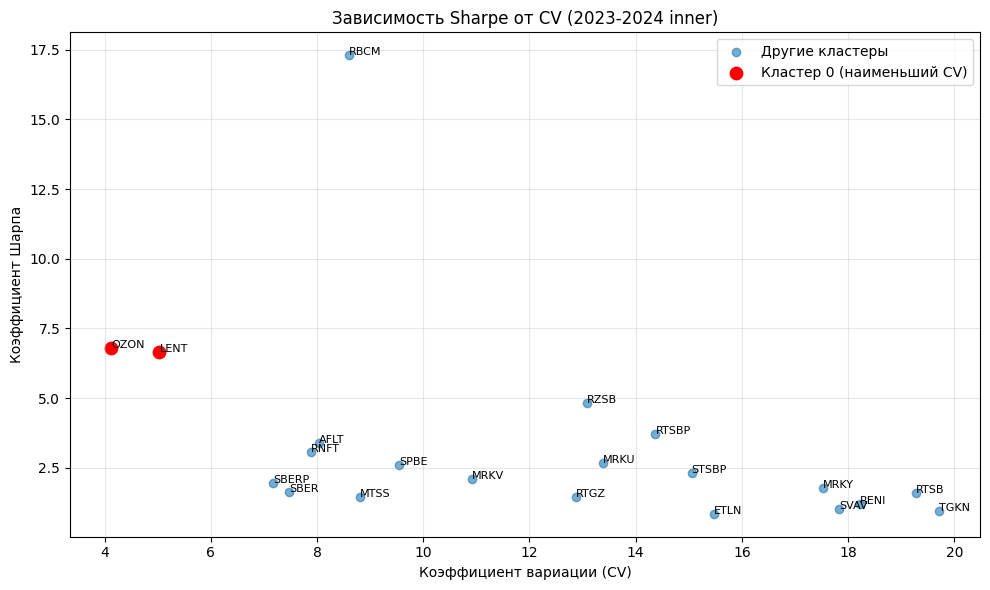

In [12]:
import matplotlib.pyplot as plt
key = ('2023_2024', 'inner')
if key in cluster_data:
    df_plot = cluster_data[key].copy()
    clusters_df = pd.read_csv(f"results/tables/clusters_{key[0]}_{key[1]}.csv")
    ticker_to_cluster = dict(zip(clusters_df['ticker'], clusters_df['cluster']))
    df_plot['cluster'] = df_plot['ticker'].map(ticker_to_cluster)
    mean_cv_by_cluster = df_plot.groupby('cluster')['cv'].mean()
    best_cluster = mean_cv_by_cluster.idxmin()
    df_plot['is_best'] = df_plot['cluster'] == best_cluster
    
    df_plot['sharpe'] = df_plot['ticker'].map(sharpe_2023)
    df_plot = df_plot.dropna()
    plt.figure(figsize=(10,6))
    plt.scatter(df_plot[~df_plot['is_best']]['cv'], df_plot[~df_plot['is_best']]['sharpe'], 
                alpha=0.6, label='Другие кластеры')
    plt.scatter(df_plot[df_plot['is_best']]['cv'], df_plot[df_plot['is_best']]['sharpe'], 
                color='red', s=80, label='Кластер 0 (наименьший CV)')
    for i, row in df_plot.iterrows():
        plt.annotate(row['ticker'], (row['cv'], row['sharpe']), fontsize=8)
    plt.xlabel('Коэффициент вариации (CV)')
    plt.ylabel('Коэффициент Шарпа')
    plt.title('Зависимость Sharpe от CV (2023-2024 inner)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/cv_sharpe_scatter.png', dpi=150)
    plt.show()

# Загрузка результатов оптимизации (из ноутбука 04)

In [14]:
corr_pairs_files = {}
corr_triples_files = {}
cluster_pairs_files = {}
cluster_triples_files = {}

for period_name, method in product(PERIODS.keys(), METHODS):
    corr_pairs_files[(period_name, method)] = f'results/tables/optimized_corr_pairs_{period_name}_{method}.csv'
    corr_triples_files[(period_name, method)] = f'results/tables/optimized_corr_triples_{period_name}_{method}.csv'
    cluster_pairs_files[(period_name, method)] = f'results/tables/optimized_cluster_pairs_{period_name}_{method}.csv'
    cluster_triples_files[(period_name, method)] = f'results/tables/optimized_cluster_triples_{period_name}_{method}.csv'

corr_opt = {'pairs': {}, 'triples': {}}
cluster_opt = {'pairs': {}, 'triples': {}}

for p, m in product(PERIODS.keys(), METHODS):
    if os.path.exists(corr_pairs_files[(p,m)]):
        corr_opt['pairs'][(p,m)] = pd.read_csv(corr_pairs_files[(p,m)])
    if os.path.exists(corr_triples_files[(p,m)]):
        corr_opt['triples'][(p,m)] = pd.read_csv(corr_triples_files[(p,m)])
    if os.path.exists(cluster_pairs_files[(p,m)]):
        cluster_opt['pairs'][(p,m)] = pd.read_csv(cluster_pairs_files[(p,m)])
    if os.path.exists(cluster_triples_files[(p,m)]):
        cluster_opt['triples'][(p,m)] = pd.read_csv(cluster_triples_files[(p,m)])

print("Загружены результаты оптимизации")

Загружены результаты оптимизации


# Сравнение результатов 2023-2024 и 2024-2025 для кластерного подхода (устойчивость)

In [16]:
def compute_stability(opt_dict, n_assets):
    """opt_dict: словарь (period, method) -> DataFrame с колонками ticker..., new_sharpe, improved"""
    stable_pairs = set()
    common_portfolios = pd.read_csv('results/tables/common_cluster_portfolios_2.csv' if n_assets==2 else 'results/tables/common_cluster_portfolios_3.csv')
    ticker_cols = [f'ticker{i+1}' for i in range(n_assets)]
    stable_count = 0
    for idx, row in common_portfolios.iterrows():
        key = tuple(sorted([row[t] for t in ticker_cols]))
        ok = True
        for period_name, method in product(PERIODS.keys(), METHODS):
            df = opt_dict.get((period_name, method))
            if df is None:
                ok = False
                break
            mask = True
            for i, t in enumerate(ticker_cols):
                mask &= (df[f'ticker{i+1}'] == row[t])
            sub = df[mask]
            if sub.empty:
                ok = False
                break
            sharpe = sub.iloc[0]['new_sharpe']
            if sharpe <= 0:
                ok = False
                break
        if ok:
            stable_count += 1
    return stable_count, len(common_portfolios)

if os.path.exists('results/tables/common_cluster_portfolios_2.csv'):
    stable_pairs, total_pairs = compute_stability(cluster_opt['pairs'], 2)
    print(f"Устойчивость кластерных пар: {stable_pairs}/{total_pairs} = {stable_pairs/total_pairs*100:.1f}%")
if os.path.exists('results/tables/common_cluster_portfolios_3.csv'):
    stable_triples, total_triples = compute_stability(cluster_opt['triples'], 3)
    print(f"Устойчивость кластерных троек: {stable_triples}/{total_triples} = {stable_triples/total_triples*100:.1f}%")

Устойчивость кластерных пар: 6/6 = 100.0%
Устойчивость кластерных троек: 1/1 = 100.0%


# Сравнение корреляционного и кластерного методов

In [18]:
def get_method_stats(opt_dict, n_assets):
    total = 0
    improved = 0
    risk_reductions = []
    sharpe_increases = []
    for df in opt_dict.values():
        if df is None or df.empty:
            continue
        total += len(df)
        improved += df['improved'].sum()
        if df['improved'].sum() > 0:
            risk_reductions.extend((df.loc[df['improved'], 'old_risk'] - df.loc[df['improved'], 'new_risk']) / df.loc[df['improved'], 'old_risk'])
            sharpe_increases.extend(df.loc[df['improved'], 'new_sharpe'] - df.loc[df['improved'], 'old_sharpe'])
    pct_improved = improved/total*100 if total>0 else 0
    avg_risk_red = np.mean(risk_reductions)*100 if risk_reductions else np.nan
    avg_sharpe_inc = np.mean(sharpe_increases) if sharpe_increases else np.nan
    return total, pct_improved, avg_risk_red, avg_sharpe_inc

corr_total, corr_pct, corr_risk, corr_sharpe = get_method_stats(corr_opt['pairs'], 2)
cluster_total, cluster_pct, cluster_risk, cluster_sharpe = get_method_stats(cluster_opt['pairs'], 2)

comparison_df = pd.DataFrame({
    'Показатель': ['Количество портфелей', 'Доля улучшившихся, %', 'Среднее снижение риска, %', 'Среднее увеличение Шарпа'],
    'Корреляционный метод': [corr_total, round(corr_pct,1), round(corr_risk,1) if not np.isnan(corr_risk) else '-', round(corr_sharpe,2) if not np.isnan(corr_sharpe) else '-'],
    'Кластерный метод': [cluster_total, round(cluster_pct,1), round(cluster_risk,1) if not np.isnan(cluster_risk) else '-', round(cluster_sharpe,2) if not np.isnan(cluster_sharpe) else '-']
})
comparison_df.to_csv('results/tables/final_comparison_table8.csv', index=False)
print("\nСравнение корреляционного и кластерного методов (портфели из двух акций с улучшением)")
print(comparison_df.to_string(index=False))


Таблица 8. Сравнение корреляционного и кластерного методов (портфели из двух акций с улучшением)
               Показатель  Корреляционный метод Кластерный метод
     Количество портфелей                204.00               24
     Доля улучшившихся, %                  2.00              0.0
Среднее снижение риска, %                 49.60                -
 Среднее увеличение Шарпа                  0.47                -


# Портфели, показавшие увеличившийся коэффициент Шарпа

In [64]:
period = '2023_2024'
method = 'inner'
pairs = [
    ('OZON', 'TGKN'),
    ('OZON', 'RTSB')
]

for t1, t2 in pairs:
    df = corr_opt['pairs'][(period, method)]
    mask = ((df['ticker1'] == t1) & (df['ticker2'] == t2)) | \
           ((df['ticker1'] == t2) & (df['ticker2'] == t1))
    row = df[mask].iloc[0]
    
    risk_eq = row['old_risk'] * 100
    risk_opt = row['new_risk'] * 100
    sharpe_eq = row['old_sharpe']
    sharpe_opt = row['new_sharpe']
    w1_opt = row['weight1_opt']
    w2_opt = row['weight2_opt']
    
    print(f"Портфель {{{t1}, {t2}}}:")
    print(f"  Равновзвешенный: σ_p = {risk_eq:.1f}%, S = {sharpe_eq:.2f}")
    print(f"  Оптимизированный: σ_p = {risk_opt:.1f}%, S = {sharpe_opt:.2f}")
    print(f"  Снижение риска: с {risk_eq:.1f}% до {risk_opt:.1f}% "
          f"({(row['old_risk']-row['new_risk'])/row['old_risk']*100:.1f}%)")
    print(f"  Рост коэффициента Шарпа: с {sharpe_eq:.2f} до {sharpe_opt:.2f} "
          f"(+{sharpe_opt-sharpe_eq:.2f})")
    print(f"  Оптимальные веса: w_{t1} = {w1_opt:.2f}, w_{t2} = {w2_opt:.2f}")
    print()

Портфель {OZON, TGKN}:
  Равновзвешенный: σ_p = 45.6%, S = 3.04
  Оптимизированный: σ_p = 29.3%, S = 3.36
  Снижение риска: с 45.6% до 29.3% (35.7%)
  Рост коэффициента Шарпа: с 3.04 до 3.36 (+0.32)
  Оптимальные веса: w_OZON = 0.89, w_TGKN = 0.11

Портфель {OZON, RTSB}:
  Равновзвешенный: σ_p = 83.4%, S = 2.81
  Оптимизированный: σ_p = 30.7%, S = 3.39
  Снижение риска: с 83.4% до 30.7% (63.2%)
  Рост коэффициента Шарпа: с 2.81 до 3.39 (+0.58)
  Оптимальные веса: w_OZON = 0.98, w_RTSB = 0.02



# Статистическая проверка значимости улучшений (парный t-тест) для всех наборов

In [54]:
def ttest_improvement_all(opt_dict):
    diffs = []
    for df in opt_dict.values():
        if df is not None and not df.empty:
            diffs.extend((df['old_risk'] - df['new_risk']).tolist())
    if len(diffs) == 0:
        return np.nan, np.nan
    t_stat, p_val = ttest_rel(diffs, np.zeros_like(diffs), alternative='greater')
    return t_stat, p_val

corr_t_pairs, corr_p_pairs = ttest_improvement_all(corr_opt['pairs'])
corr_t_triples, corr_p_triples = ttest_improvement_all(corr_opt['triples'])
cluster_t_pairs, cluster_p_pairs = ttest_improvement_all(cluster_opt['pairs'])
cluster_t_triples, cluster_p_triples = ttest_improvement_all(cluster_opt['triples'])

ttest_df = pd.DataFrame({
    'Подход': ['Корреляционный', 'Корреляционный', 'Кластерный', 'Кластерный'],
    'Размер': [2, 3, 2, 3],
    't-статистика': [corr_t_pairs, corr_t_triples, cluster_t_pairs, cluster_t_triples],
    'p-значение (односторонний)': [corr_p_pairs, corr_p_triples, cluster_p_pairs, cluster_p_triples]
})
ttest_df.to_csv('results/tables/paired_ttest_results.csv', index=False)
print("\nСтатистическая значимость улучшений (парный t-тест):")
print(ttest_df.to_string(index=False))


Статистическая значимость улучшений (парный t-тест):
        Подход  Размер  t-статистика  p-значение (односторонний)
Корреляционный       2     14.069688                3.928827e-32
Корреляционный       3     13.997602                7.189469e-22
    Кластерный       2      2.474233                1.058048e-02
    Кластерный       3      3.098573                2.667747e-02


# Анализ влияния обработки пропусков (inner join vs forward fill)

Средний Sharpe (inner): 8.8701
Средний Sharpe (ffill): 8.9535
Различие: -0.0834


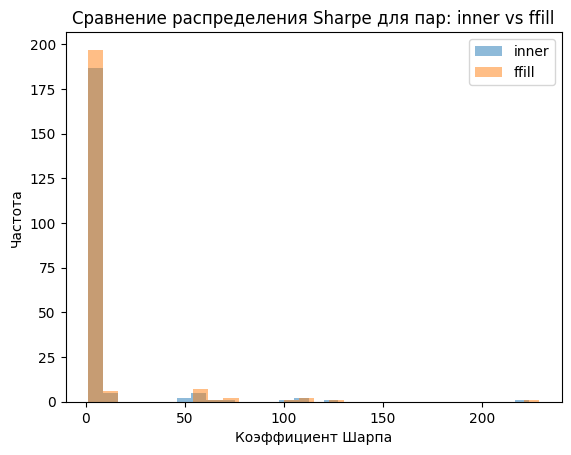

In [22]:
inner_vals = []
ffill_vals = []
for period_name in PERIODS.keys():
    for method in METHODS:
        fname = f'results/tables/pairs_corr_{CORR_LOWER}_to_{CORR_UPPER}_{period_name}_{method}.csv'
        if not os.path.exists(fname):
            continue
        df = pd.read_csv(fname)
        sharpe_col = 'sharpe' if 'sharpe' in df.columns else 'old_sharpe'  # в зависимости от версии
        if method == 'inner':
            inner_vals.extend(df[sharpe_col].dropna().tolist())
        else:
            ffill_vals.extend(df[sharpe_col].dropna().tolist())
print(f"Средний Sharpe (inner): {np.mean(inner_vals):.4f}")
print(f"Средний Sharpe (ffill): {np.mean(ffill_vals):.4f}")
print(f"Различие: {np.mean(inner_vals)-np.mean(ffill_vals):.4f}")

plt.figure()
plt.hist(inner_vals, alpha=0.5, label='inner', bins=30)
plt.hist(ffill_vals, alpha=0.5, label='ffill', bins=30)
plt.xlabel('Коэффициент Шарпа')
plt.ylabel('Частота')
plt.title('Сравнение распределения Sharpe для пар: inner vs ffill')
plt.legend()
plt.savefig('results/figures/sharpe_inner_vs_ffill.png', dpi=150)
plt.show()

# Анализ кластерной принадлежности акций из эффективных корреляционных портфелей

In [24]:
df_opt_pairs = corr_opt['pairs'].get(('2023_2024', 'inner'))
if df_opt_pairs is not None and not df_opt_pairs.empty:
    clusters_2324_inner = pd.read_csv('results/tables/clusters_2023_2024_inner.csv')
    ticker_to_cluster = dict(zip(clusters_2324_inner['ticker'], clusters_2324_inner['cluster']))
    
    cluster_counts = {}
    for _, row in df_opt_pairs.iterrows():
        for t in [row['ticker1'], row['ticker2']]:
            cl = ticker_to_cluster.get(t)
            if cl is not None:
                cluster_counts[cl] = cluster_counts.get(cl, 0) + 1
    total = sum(cluster_counts.values())
    print("\nРаспределение акций из всех корреляционных пар по кластерам:")
    for cl, cnt in sorted(cluster_counts.items()):
        print(f"  Кластер {cl}: {cnt} ({cnt/total*100:.1f}%)")
    # Сохраним таблицу
    cluster_dist = pd.DataFrame([{'cluster': cl, 'count': cnt, 'percent': cnt/total*100} for cl, cnt in cluster_counts.items()])
    cluster_dist.to_csv('results/tables/all_corr_pairs_cluster_distribution.csv', index=False)
else:
    print("Нет данных по оптимизированным парам для 2023_2024 inner.")

df_opt_triples = corr_opt['triples'].get(('2023_2024', 'inner'))
if df_opt_triples is not None and not df_opt_triples.empty:
    clusters_2324_inner = pd.read_csv('results/tables/clusters_2023_2024_inner.csv')
    ticker_to_cluster = dict(zip(clusters_2324_inner['ticker'], clusters_2324_inner['cluster']))
    
    cluster_counts = {}
    for _, row in df_opt_triples.iterrows():
        for t in [row['ticker1'], row['ticker2'], row['ticker3']]:
            cl = ticker_to_cluster.get(t)
            if cl is not None:
                cluster_counts[cl] = cluster_counts.get(cl, 0) + 1
    total = sum(cluster_counts.values())
    print("\nРаспределение акций из всех корреляционных троек по кластерам:")
    for cl, cnt in sorted(cluster_counts.items()):
        print(f"  Кластер {cl}: {cnt} ({cnt/total*100:.1f}%)")
 
    cluster_dist_triples = pd.DataFrame([{'cluster': cl, 'count': cnt, 'percent': cnt/total*100} for cl, cnt in cluster_counts.items()])
    cluster_dist_triples.to_csv('results/tables/all_corr_triples_cluster_distribution.csv', index=False)
else:
    print("Нет данных по оптимизированным тройкам для 2023_2024 inner.")




Распределение акций из ВСЕХ корреляционных пар по кластерам:
  Кластер 0: 33 (32.4%)
  Кластер 1: 22 (21.6%)
  Кластер 2: 7 (6.9%)
  Кластер 3: 40 (39.2%)

Распределение акций из ВСЕХ корреляционных троек по кластерам:
  Кластер 0: 14 (27.5%)
  Кластер 1: 9 (17.6%)
  Кластер 2: 1 (2.0%)
  Кластер 3: 27 (52.9%)


# Анализ влияния дивидендов


Влияние дивидендов:
in_cluster0
False    0.0
Name: div_yield, dtype: float64


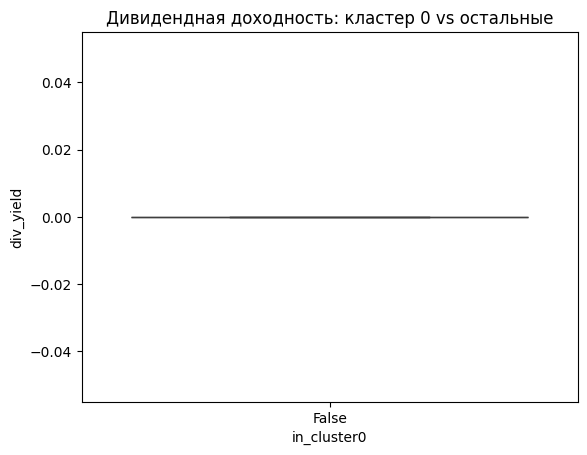

In [26]:
dividend_data = []
for ticker in pd.read_csv('results/tables/top21_tickers.csv')['ticker'].tolist():
    for period_name, period in PERIODS.items():
        start = pd.to_datetime(period['start'])
        end = pd.to_datetime(period['end'])
        div_sum = get_dividends_sum(ticker, start, end)
        pkl = load_prices_dict(os.path.join('data', period['pkl_file']))
        prices = pkl.get(ticker)
        if prices is not None:
            avg_price = prices.mean()
            div_yield = div_sum / avg_price if avg_price>0 else 0
        else:
            div_yield = 0
        dividend_data.append({'ticker': ticker, 'period': period_name, 'div_sum': div_sum, 'div_yield': div_yield})
df_div = pd.DataFrame(dividend_data)
cluster0_tickers = pd.read_csv('results/tables/cluster0_common_all.csv')['ticker'].tolist() if os.path.exists('results/tables/cluster0_common_all.csv') else []
df_div['in_cluster0'] = df_div['ticker'].isin(cluster0_tickers)
print("\nВлияние дивидендов:")
print(df_div.groupby('in_cluster0')['div_yield'].mean())

# Анализ устойчивости портфелей при разных методах обработки пропусков

In [30]:
for period_name in PERIODS.keys():
    inner_sharpe = []
    ffill_sharpe = []
    for method in METHODS:
        fname = f'results/tables/pairs_corr_{CORR_LOWER}_to_{CORR_UPPER}_{period_name}_{method}.csv'
        if os.path.exists(fname):
            df = pd.read_csv(fname)
            sharpe_col = 'sharpe' if 'sharpe' in df.columns else 'old_sharpe'
            if method == 'inner':
                inner_sharpe.extend(df[sharpe_col].dropna().tolist())
            else:
                ffill_sharpe.extend(df[sharpe_col].dropna().tolist())
    if inner_sharpe and ffill_sharpe:
        print(f"{period_name}: inner Sharpe mean = {np.mean(inner_sharpe):.3f}, ffill Sharpe mean = {np.mean(ffill_sharpe):.3f}")

2023_2024: inner Sharpe mean = 3.513, ffill Sharpe mean = 3.454
2024_2025: inner Sharpe mean = 15.775, ffill Sharpe mean = 15.325


# Построение гистограммы распределения коэффициентов Шарпа для отобранных портфелей

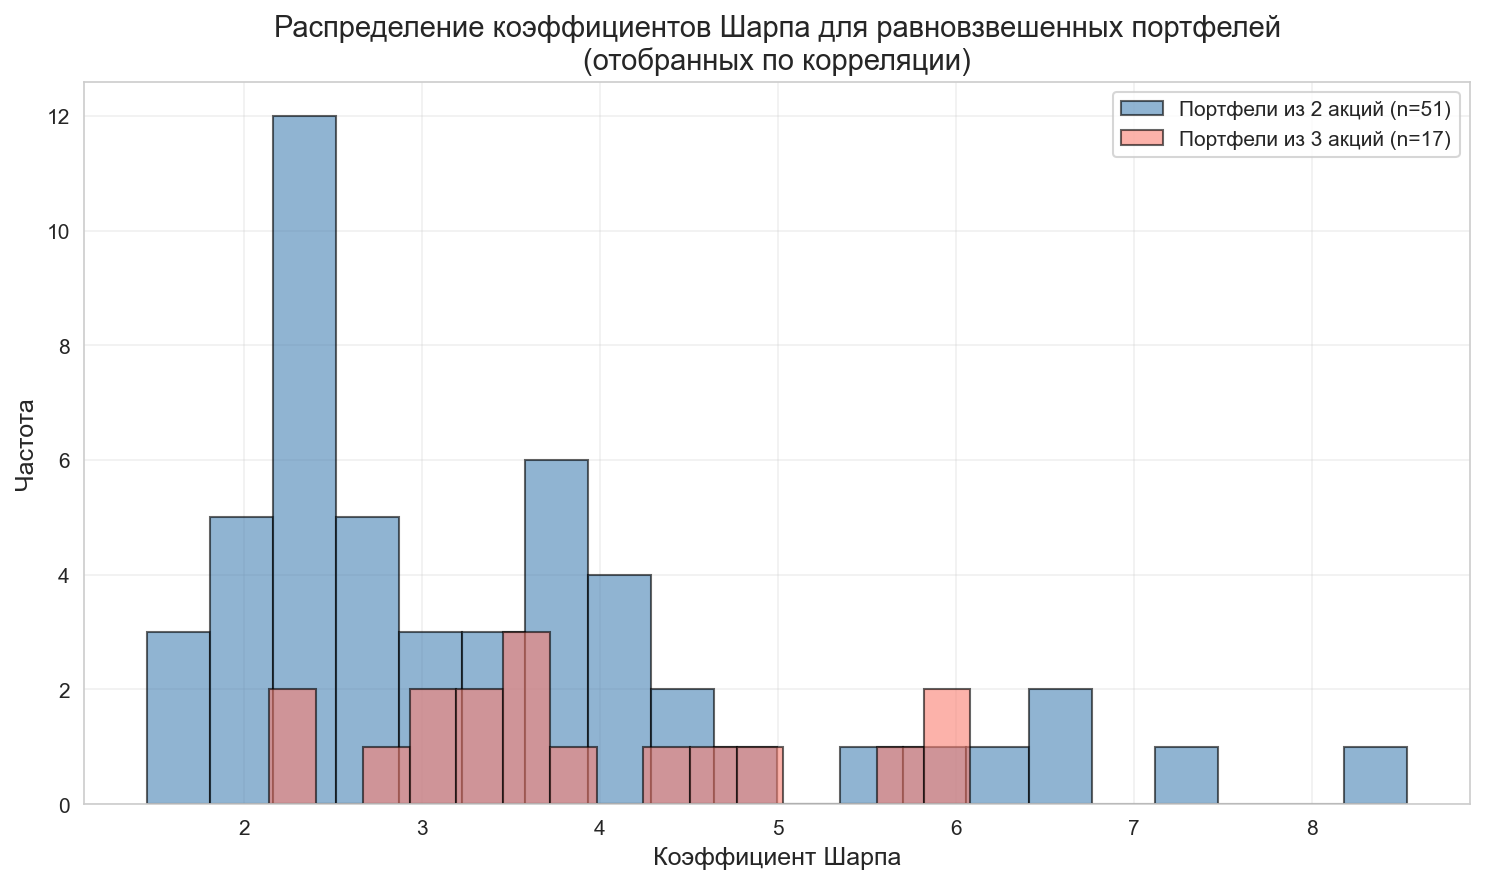

Гистограмма сохранена: results/figures/sharpe_distribution.png
Средний Sharpe для пар: 3.42, медиана: 2.87
Средний Sharpe для троек: 3.90, медиана: 3.66


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

pairs = pd.read_csv('results/tables/common_pairs_all_datasets.csv')
triples = pd.read_csv('results/tables/common_triples_all_datasets.csv')

sharpe_pairs = pairs['sharpe'].dropna()
sharpe_triples = triples['sharpe'].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(sharpe_pairs, bins=20, alpha=0.6, label=f'Портфели из 2 акций (n={len(sharpe_pairs)})', 
        color='steelblue', edgecolor='black')

if len(sharpe_triples) > 0:
    ax.hist(sharpe_triples, bins=15, alpha=0.6, label=f'Портфели из 3 акций (n={len(sharpe_triples)})',
            color='salmon', edgecolor='black')

ax.set_xlabel('Коэффициент Шарпа', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Распределение коэффициентов Шарпа для равновзвешенных портфелей\n(отобранных по корреляции)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/sharpe_distribution.png')
plt.show()

print(f"Гистограмма сохранена: results/figures/sharpe_distribution.png")
print(f"Средний Sharpe для пар: {sharpe_pairs.mean():.2f}, медиана: {sharpe_pairs.median():.2f}")
if len(sharpe_triples) > 0:
    print(f"Средний Sharpe для троек: {sharpe_triples.mean():.2f}, медиана: {sharpe_triples.median():.2f}")